# Model Robustness Under Distribution Shift


## 1. Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor

## 2. Load Preprocessed Data


In [24]:
train_df = pd.read_csv("data/flood_train_scaled.csv")
test_df = pd.read_csv("data/flood_test_scaled.csv")

TARGET = "FloodProbability"
feature_cols = [c for c in train_df.columns if c != TARGET]

# Reconstruct full scaled dataset for subset splitting
df = pd.concat([train_df, test_df], ignore_index=True)

print(f"Train shape : {train_df.shape}")
print(f"Test shape  : {test_df.shape}")
print(f"Combined    : {df.shape}")
print(f"\nFloodProbability mean : {df[TARGET].mean():.4f}")
print(f"FloodProbability std  : {df[TARGET].std():.4f}")

Train shape : (40000, 21)
Test shape  : (10000, 21)
Combined    : (50000, 21)

FloodProbability mean : 0.4997
FloodProbability std  : 0.0500


## 3. Define High-Risk and Low-Risk Subsets

We define the **high-risk** (shifted) subset as observations where both `ClimateChange`
and `Urbanization` exceed their respective 75th percentiles. The 75th percentile is selected as the threshold following WMO/ETCCDI standard practice, where the upper quartile (R75) is an established index for identifying high-intensity climate conditions (Peterson et al., 2001; WMO, 2009). This choice ensures the shifted subset captures the top quarter of ClimateChange and Urbanization values jointly while retaining sufficient sample size for model evaluation.

The remaining samples form the **baseline** (lower-risk) subset, on which we train
all three models. This mirrors real-world deployment: a model trained on historical,
predominantly lower-risk data is later applied to a higher-risk environment it has
never seen.

In [25]:
threshold_cc = df["ClimateChange"].quantile(0.75)
threshold_ur = df["Urbanization"].quantile(0.75)

print(f"ClimateChange  75th percentile threshold : {threshold_cc:.4f}")
print(f"Urbanization   75th percentile threshold : {threshold_ur:.4f}")

high_risk_mask = (df["ClimateChange"] > threshold_cc) & (
    df["Urbanization"] > threshold_ur
)
low_risk_mask = ~high_risk_mask

df_baseline = df[low_risk_mask].reset_index(drop=True)
df_shifted = df[high_risk_mask].reset_index(drop=True)

print(
    f"\nBaseline (lower-risk) subset size : {len(df_baseline):,} ({len(df_baseline)/len(df)*100:.1f}%)"
)
print(
    f"Shifted  (higher-risk) subset size: {len(df_shifted):,} ({len(df_shifted)/len(df)*100:.1f}%)"
)
print(f"\nBaseline mean FloodProbability    : {df_baseline[TARGET].mean():.4f}")
print(f"Shifted  mean FloodProbability    : {df_shifted[TARGET].mean():.4f}")

ClimateChange  75th percentile threshold : 0.9528
Urbanization   75th percentile threshold : 0.6430

Baseline (lower-risk) subset size : 47,277 (94.6%)
Shifted  (higher-risk) subset size: 2,723 (5.4%)

Baseline mean FloodProbability    : 0.4979
Shifted  mean FloodProbability    : 0.5305


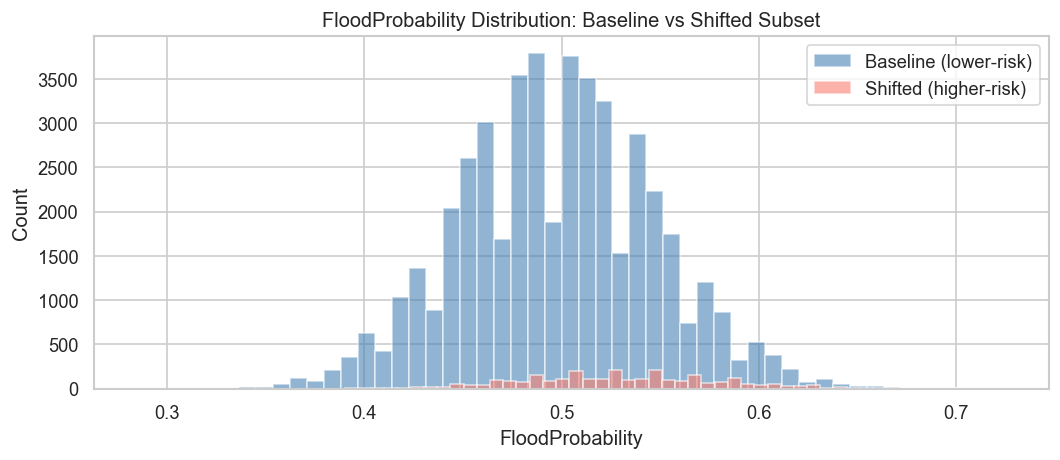

In [26]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(
    df_baseline[TARGET],
    bins=50,
    alpha=0.6,
    color="steelblue",
    label="Baseline (lower-risk)",
    edgecolor="white",
)
ax.hist(
    df_shifted[TARGET],
    bins=50,
    alpha=0.6,
    color="salmon",
    label="Shifted (higher-risk)",
    edgecolor="white",
)
ax.set_xlabel("FloodProbability")
ax.set_ylabel("Count")
ax.set_title("FloodProbability Distribution: Baseline vs Shifted Subset")
ax.legend()
plt.tight_layout()
plt.show()

The high-risk subset is defined as observations where both ClimateChange and Urbanization
exceed their respective 75th percentile thresholds (0.953 and 0.643 in standardized units).
This produces a shifted subset of 2,723 samples (5.4% of the full dataset), with the
remaining 47,277 samples (94.6%) forming the baseline training set. As expected, the
shifted subset shows a higher mean FloodProbability (0.5305 vs 0.4979), which means
that simultaneously elevated ClimateChange and Urbanization do correspond to elevated flood
risk. The shifted subset appears to have a higher concentration of values in the upper range, indicating increased flood risk, although the overall shape remains similar and heavily overlapping with the baseline distribution.

## 4. Train / Test Split

The data is already scaled from preprocessing. We split each subset into features and
target directly — no re-scaling needed. The baseline subset is used for training;
the shifted subset serves as the out-of-distribution test set.

In [27]:
X_train = df_baseline[feature_cols].copy()
y_train = df_baseline[TARGET].copy()

X_test = df_shifted[feature_cols].copy()
y_test = df_shifted[TARGET].copy()

print(f"X_train shape : {X_train.shape}")
print(f"X_test  shape : {X_test.shape}")

X_train shape : (47277, 20)
X_test  shape : (2723, 20)


## 5. Evaluation Helpers

In [28]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)


def evaluate(y_true, y_pred, model_name, split_name):
    return pd.DataFrame(
        {
            "Model": [model_name],
            "Split": [split_name],
            "R2": [round(r2_score(y_true, y_pred), 6)],
            "RMSE": [round(np.sqrt(mean_squared_error(y_true, y_pred)), 6)],
            "MAE": [round(mean_absolute_error(y_true, y_pred), 6)],
        }
    )


def residual_plots(y_true, y_pred, model_name, split_name):
    residuals = np.array(y_true) - np.array(y_pred)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].scatter(y_pred, residuals, alpha=0.3, s=10, color="steelblue")
    axes[0].axhline(0, color="red", linestyle="--")
    axes[0].set_xlabel("Predicted FloodProbability")
    axes[0].set_ylabel("Residuals")
    axes[0].set_title(f"{model_name} [{split_name}]: Residuals vs Fitted")

    axes[1].hist(residuals, bins=40, color="steelblue", edgecolor="white")
    axes[1].set_xlabel("Residual")
    axes[1].set_ylabel("Count")
    axes[1].set_title(f"{model_name} [{split_name}]: Residual Distribution")

    plt.tight_layout()
    plt.show()


def stratified_error_table(X, y_true, y_pred, stratify_col, q=4):
    df_eval = X.copy()
    df_eval["actual"] = np.array(y_true)
    df_eval["pred"] = np.array(y_pred)
    df_eval["abs_error"] = np.abs(df_eval["actual"] - df_eval["pred"])
    df_eval["bin"] = pd.qcut(df_eval[stratify_col], q=q, duplicates="drop")

    out = (
        df_eval.groupby("bin", observed=False)
        .agg(
            n=("abs_error", "size"),
            mean_abs_error=("abs_error", "mean"),
            rmse=(
                "pred",
                lambda s: np.sqrt(np.mean((df_eval.loc[s.index, "actual"] - s) ** 2)),
            ),
        )
        .reset_index()
    )
    return out

## 6. Model 1: Multiple Linear Regression

We train the linear regression model on the baseline subset and evaluate it on both
subsets to measure performance degradation under distribution shift.

Linear Regression — Baseline vs Shifted


,Model,Split,R2,RMSE,MAE
0,Linear Regression,Baseline (lower-risk),0.588383,0.031765,0.025151
1,Linear Regression,Shifted (higher-risk),0.548349,0.032954,0.026215


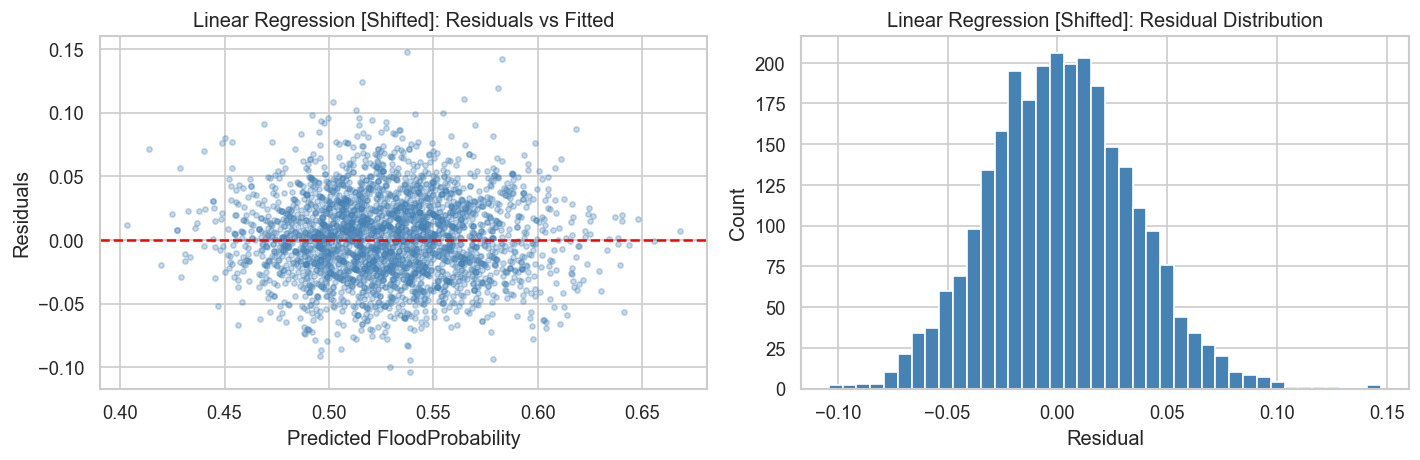

Linear Regression error by ClimateChange quartile (Shifted subset):


,bin,n,mean_abs_error,rmse
0,"(1.3490000000000002, 1.401]",1219,0.026096,0.032721
1,"(1.401, 1.85]",746,0.025786,0.032575
2,"(1.85, 2.298]",423,0.026525,0.033768
3,"(2.298, 5.886]",335,0.027214,0.033589


Linear Regression error by Urbanization quartile (Shifted subset):


,bin,n,mean_abs_error,rmse
0,"(0.643, 0.899]",781,0.025845,0.032279
1,"(0.899, 1.202]",581,0.026864,0.033436
2,"(1.202, 1.717]",680,0.026901,0.034185
3,"(1.717, 5.417]",681,0.025402,0.032039


In [29]:
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

lin_train_pred = lin_model.predict(X_train)
lin_shift_pred = lin_model.predict(X_test)

lin_base_result = evaluate(
    y_train, lin_train_pred, "Linear Regression", "Baseline (lower-risk)"
)
lin_shift_result = evaluate(
    y_test, lin_shift_pred, "Linear Regression", "Shifted (higher-risk)"
)

print("Linear Regression — Baseline vs Shifted")
display(pd.concat([lin_base_result, lin_shift_result], ignore_index=True))

residual_plots(y_test, lin_shift_pred, "Linear Regression", "Shifted")

print("Linear Regression error by ClimateChange quartile (Shifted subset):")
display(stratified_error_table(X_test, y_test, lin_shift_pred, "ClimateChange"))

print("Linear Regression error by Urbanization quartile (Shifted subset):")
display(stratified_error_table(X_test, y_test, lin_shift_pred, "Urbanization"))

Linear Regression proves to be the most robust model under distribution shift, with R²
dropping only marginally from 0.5884 on the baseline to 0.5483 on the shifted subset. RMSE increases slightly from 0.0318 to 0.0330, and MAE from 0.0252 to 0.0262, both remaining at low and comparable levels. Since the preprocessing-injected noise is
additive and the underlying data-generating process is fundamentally linear, the coefficients
learned on the baseline subset transfer well to the high-risk feature space. The stratified
error analysis shows no meaningful degradation across ClimateChange or Urbanization quartiles
in the shifted subset, RMSE stays in the 0.032–0.034 range throughout, which means
the model is not introducing directional bias when applied to out-of-distribution conditions.

## 7. Model 2: XGBoost Regressor

XGBoost is trained on the baseline subset using the same hyperparameters as in
`01_modeling.ipynb` to ensure a fair comparison.

XGBoost — Baseline vs Shifted


,Model,Split,R2,RMSE,MAE
0,XGBoost,Baseline (lower-risk),0.671827,0.028363,0.022440
1,XGBoost,Shifted (higher-risk),0.551323,0.032845,0.026047


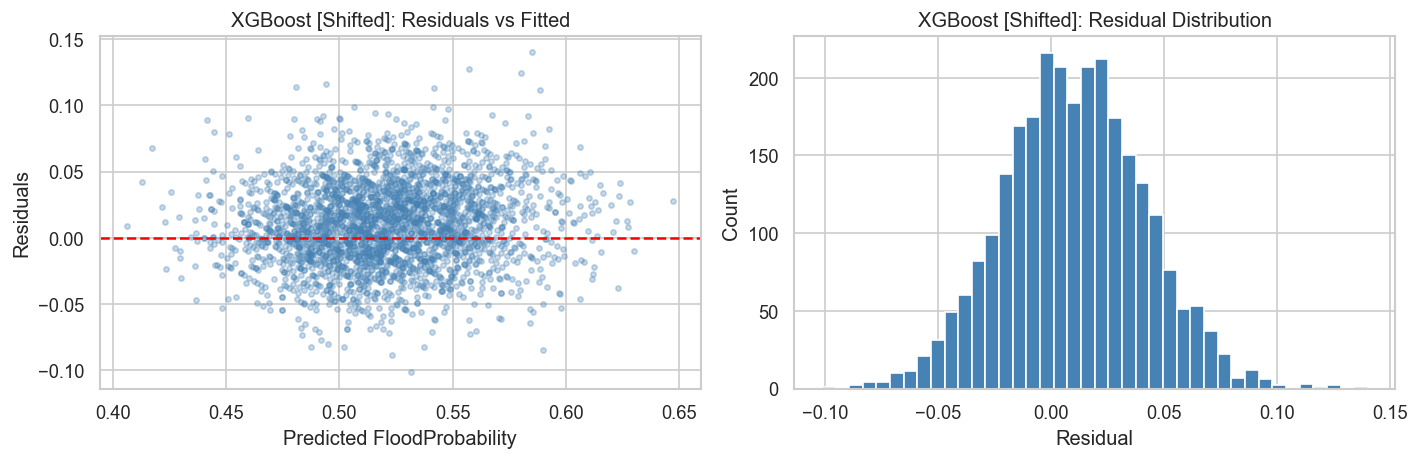

XGBoost error by ClimateChange quartile (Shifted subset):


,bin,n,mean_abs_error,rmse
0,"(1.3490000000000002, 1.401]",1219,0.025568,0.031924
1,"(1.401, 1.85]",746,0.025294,0.032151
2,"(1.85, 2.298]",423,0.027059,0.034749
3,"(2.298, 5.886]",335,0.028195,0.035123


XGBoost error by Urbanization quartile (Shifted subset):


,bin,n,mean_abs_error,rmse
0,"(0.643, 0.899]",781,0.025228,0.031448
1,"(0.899, 1.202]",581,0.025684,0.032324
2,"(1.202, 1.717]",680,0.026587,0.034098
3,"(1.717, 5.417]",681,0.026759,0.033570


In [30]:
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_alpha=0.01,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
)
xgb_model.fit(X_train, y_train)

xgb_train_pred = xgb_model.predict(X_train)
xgb_shift_pred = xgb_model.predict(X_test)

xgb_base_result = evaluate(y_train, xgb_train_pred, "XGBoost", "Baseline (lower-risk)")
xgb_shift_result = evaluate(y_test, xgb_shift_pred, "XGBoost", "Shifted (higher-risk)")

print("XGBoost — Baseline vs Shifted")
display(pd.concat([xgb_base_result, xgb_shift_result], ignore_index=True))

residual_plots(y_test, xgb_shift_pred, "XGBoost", "Shifted")

print("XGBoost error by ClimateChange quartile (Shifted subset):")
display(stratified_error_table(X_test, y_test, xgb_shift_pred, "ClimateChange"))

print("XGBoost error by Urbanization quartile (Shifted subset):")
display(stratified_error_table(X_test, y_test, xgb_shift_pred, "Urbanization"))

XGBoost shows a more pronounced performance drop under distribution shift compared to
Linear Regression, with R² falling from 0.6718 on the baseline to 0.5513 on the shifted
subset. RMSE increases from 0.0284 to 0.0328 and MAE from
0.0224 to 0.0260, representing roughly a 16% increase in both error metrics. This reflects a known limitation of tree-based ensemble models: they interpolate
well within the training distribution but struggle to generalize to corners of the feature
space that are underrepresented during training. Since the shifted subset consists of
samples with simultaneously high ClimateChange and Urbanization — only 5.4% of the full
dataset — XGBoost has seen relatively few such examples. The stratified error analysis
reveals a clear gradient: RMSE rises from 0.0319 in the lowest ClimateChange quartile to
0.0351 in the highest, which means the model systematically struggles more as climate stress
intensifies. A similar pattern holds for Urbanization (0.0314 to 0.0336), so XGBoost tends to underestimate flood probability in the most extreme high-risk conditions.

## 8. Model 3: Sparse Decision Tree Regressor

 

Best Sparse Tree Params: {'ccp_alpha': np.float64(0.0), 'max_depth': 5, 'min_samples_leaf': 25}
Sparse Decision Tree — Baseline vs Shifted


,Model,Split,R2,RMSE,MAE
0,Sparse Decision Tree,Baseline (lower-risk),0.181167,0.044802,0.035812
1,Sparse Decision Tree,Shifted (higher-risk),-0.215671,0.054064,0.042994


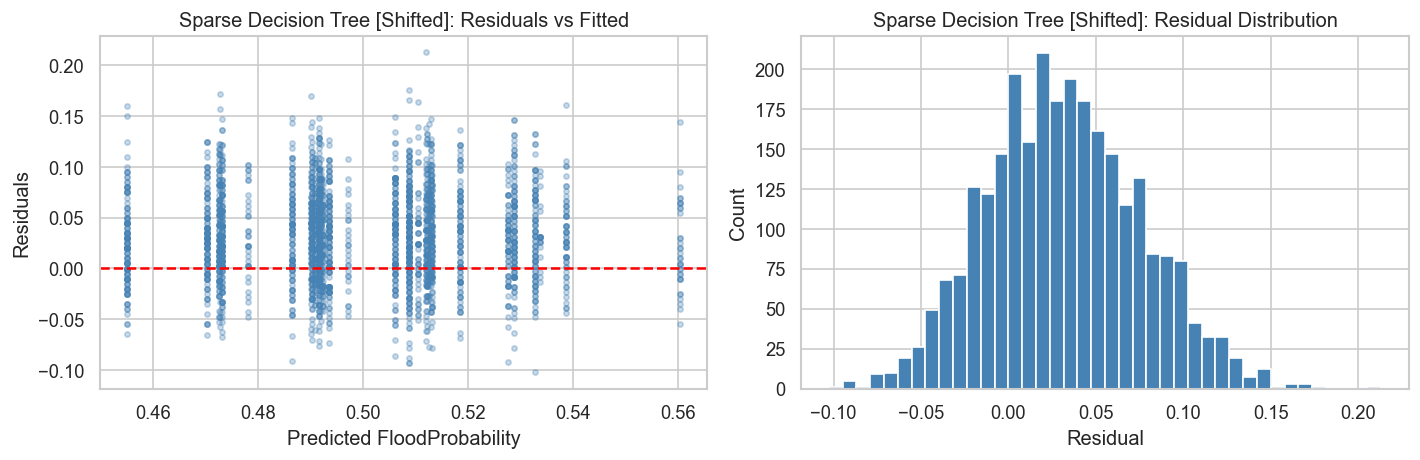

Sparse Decision Tree error by ClimateChange quartile (Shifted subset):


,bin,n,mean_abs_error,rmse
0,"(1.3490000000000002, 1.401]",1219,0.039642,0.050075
1,"(1.401, 1.85]",746,0.041819,0.052741
2,"(1.85, 2.298]",423,0.046735,0.058109
3,"(2.298, 5.886]",335,0.053081,0.064625


Sparse Decision Tree error by Urbanization quartile (Shifted subset):


,bin,n,mean_abs_error,rmse
0,"(0.643, 0.899]",781,0.039865,0.050039
1,"(0.899, 1.202]",581,0.040535,0.051371
2,"(1.202, 1.717]",680,0.043305,0.054464
3,"(1.717, 5.417]",681,0.048368,0.060020


In [31]:
base_tree = DecisionTreeRegressor(random_state=42)
path = base_tree.cost_complexity_pruning_path(X_train, y_train)
candidate_alphas = np.unique(np.round(path.ccp_alphas, 6))
candidate_alphas = candidate_alphas[candidate_alphas >= 0]

param_grid = {
    "max_depth": [2, 3, 4, 5],
    "min_samples_leaf": [25, 50, 100],
    "ccp_alpha": candidate_alphas,
}

sot_grid = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=param_grid,
    scoring="r2",
    cv=cv,
    n_jobs=-1,
    refit=True,
)
sot_grid.fit(X_train, y_train)
tree_model = sot_grid.best_estimator_

print("Best Sparse Tree Params:", sot_grid.best_params_)

tree_train_pred = tree_model.predict(X_train)
tree_shift_pred = tree_model.predict(X_test)

tree_base_result = evaluate(
    y_train, tree_train_pred, "Sparse Decision Tree", "Baseline (lower-risk)"
)
tree_shift_result = evaluate(
    y_test, tree_shift_pred, "Sparse Decision Tree", "Shifted (higher-risk)"
)

print("Sparse Decision Tree — Baseline vs Shifted")
display(pd.concat([tree_base_result, tree_shift_result], ignore_index=True))

residual_plots(y_test, tree_shift_pred, "Sparse Decision Tree", "Shifted")

print("Sparse Decision Tree error by ClimateChange quartile (Shifted subset):")
display(stratified_error_table(X_test, y_test, tree_shift_pred, "ClimateChange"))

print("Sparse Decision Tree error by Urbanization quartile (Shifted subset):")
display(stratified_error_table(X_test, y_test, tree_shift_pred, "Urbanization"))

The Sparse Decision Tree exhibits the most severe performance degradation of all three
models, with R² collapsing from 0.1812 on the baseline to −0.2157 on the shifted subset. A negative R² means the model performs worse than simply
predicting the mean of the target variable, which is a complete breakdown of predictive
ability. RMSE and MAE increase substantially, from 0.0448 to 0.0541 and from 0.0358 to
0.0430 respectively. This outcome is not surprising given the model's structural constraints:
with a maximum depth of 5, the tree is limited to 32 leaf nodes and can only capture
coarse, high-level decision boundaries. When applied to the shifted subset, where feature
combinations lie outside the regions most heavily represented in training, those coarse
boundaries fail entirely. The stratified error analysis makes the collapse concrete:
RMSE in the highest ClimateChange quartile reaches 0.0646, nearly double the 0.0319
observed for Linear Regression in the same bin. The residual plot shows predictions
concentrated in a narrow range of discrete values (vertical stripes), with residuals
widely scattered and no centering around zero.

## 9. Final Robustness Comparison

In [32]:
all_results = pd.concat(
    [
        lin_base_result,
        lin_shift_result,
        xgb_base_result,
        xgb_shift_result,
        tree_base_result,
        tree_shift_result,
    ],
    ignore_index=True,
)

print("Full Results Table")
display(all_results)

# R² degradation per model
degradation_rows = []
for model_name in all_results["Model"].unique():
    subset = all_results[all_results["Model"] == model_name]
    r2_base = subset[subset["Split"].str.contains("lower")]["R2"].values[0]
    r2_shift = subset[subset["Split"].str.contains("higher")]["R2"].values[0]
    degradation_rows.append(
        {
            "Model": model_name,
            "Baseline R2": round(r2_base, 4),
            "Shifted R2": round(r2_shift, 4),
            "R2 Degradation": round(r2_base - r2_shift, 4),
        }
    )

degradation_df = pd.DataFrame(degradation_rows).sort_values(
    "R2 Degradation", ascending=False
)
print("\nR² Degradation under Distribution Shift")
display(degradation_df)

Full Results Table


,Model,Split,R2,RMSE,MAE
0,Linear Regression,Baseline (lower-risk),0.588383,0.031765,0.025151
1,Linear Regression,Shifted (higher-risk),0.548349,0.032954,0.026215
2,XGBoost,Baseline (lower-risk),0.671827,0.028363,0.022440
3,XGBoost,Shifted (higher-risk),0.551323,0.032845,0.026047
4,Sparse Decision Tree,Baseline (lower-risk),0.181167,0.044802,0.035812
5,Sparse Decision Tree,Shifted (higher-risk),-0.215671,0.054064,0.042994



R² Degradation under Distribution Shift


,Model,Baseline R2,Shifted R2,R2 Degradation
2,Sparse Decision Tree,0.1812,-0.2157,0.3968
1,XGBoost,0.6718,0.5513,0.1205
0,Linear Regression,0.5884,0.5483,0.0400


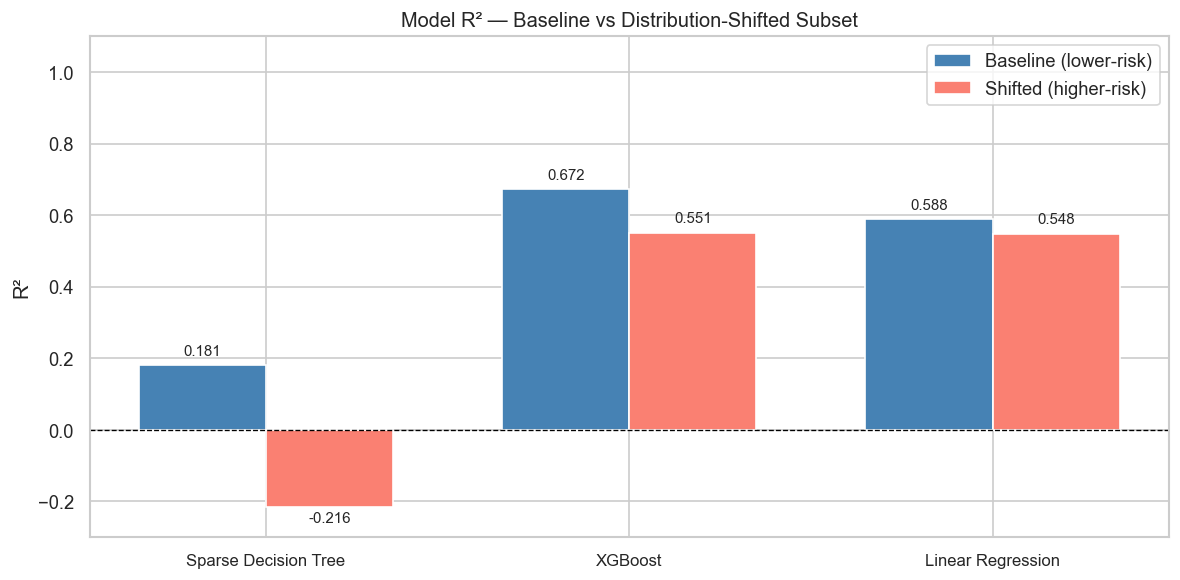

In [33]:
models = degradation_df["Model"].tolist()
x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(
    x - width / 2,
    degradation_df["Baseline R2"],
    width,
    label="Baseline (lower-risk)",
    color="steelblue",
    edgecolor="white",
)
bars2 = ax.bar(
    x + width / 2,
    degradation_df["Shifted R2"],
    width,
    label="Shifted (higher-risk)",
    color="salmon",
    edgecolor="white",
)

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=10)
ax.set_ylabel("R²")
ax.set_title("Model R² — Baseline vs Distribution-Shifted Subset")
ax.legend()
ax.set_ylim(-0.3, 1.1)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")

for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        h + 0.02 if h >= 0 else h - 0.05,
        f"{h:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

Linear Regression is the most robust model, with an R² degradation of only 0.0400.
Its parametric, globally-fitted nature means that the linear relationships learned on
the baseline subset transfer well to the high-risk conditions.

XGBoost falls in the middle, with a degradation of 0.1205. While it achieves the
strongest baseline performance (R² = 0.6718), its reliance on locally-fitted trees
makes it more sensitive to distribution shift. The model has seen relatively few examples
of simultaneously high ClimateChange and Urbanization during training and cannot
generalize as effectively to that corner of the feature space.

The Sparse Decision Tree suffers the most, with a degradation of 0.3968 and a negative
shifted R² of −0.2157. Its shallow depth and aggressive pruning become catastrophic under
distribution shift. The model lacks both the resolution and the flexibility to adapt
to the new input distribution.

## 10. Ethical Risk Discussion

The distribution shift analysis surfaces an important ethical concern: if our models
perform systematically worse on the high-risk subset — precisely the regions
characterized by high urbanization and intensifying climate stress — then the
communities most vulnerable to flooding are also the ones receiving the least
reliable predictions.

This pattern reflects a broader issue of infrastructural bias in predictive modeling.
Areas with poor drainage systems, inadequate planning, and limited disaster preparedness
tend to cluster in the high-risk subset. If a model trained predominantly on lower-risk
conditions is deployed in these regions, it may:

- **Underestimate flood probability**, leading to insufficient preparation and resource allocation
- **Systematically disadvantage infrastructure-poor areas**, where decision-makers rely more heavily on predictive tools due to limited local capacity
- **Reinforce existing inequalities**, as prediction errors in high-risk regions translate directly to delayed emergency response and greater human and economic loss

These risks are not hypothetical: XGBoost’s tendency to underestimate flood probability
in high-risk conditions (visible in the positive residual skew) is exactly the failure
mode that would lead to under-preparedness in the communities that can least afford it.